# Readout Charge-Gate Power with Reference — Analyzer Development
Prototype a new analyzer step by step.  
Load a pre-parsed `xarray.Dataset` from an `.h5` file and explore the raw data.

In [1]:

import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [2]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng_01\two_step\ro_charge_power_stable_merged.h5"

# Optional: paths for saving outputs (set to None to skip saving)
METADATA_SAVE_PATH = None   # e.g. r"output/state_disc_results.pkl"
FIGURE_SAVE_PATH   = None   # e.g. r"output/state_disc"

# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "user_mean": [[0.1, 0.2], [0.3, 0.4]],  # initial guess for GMM centers
    # "user_std": 0.05,                         # initial guess for Gaussian std
    # "outlier_sigma": 3,                       # outlier detection threshold
}

## 2. Load Dataset

In [3]:
dataset = load_xarray_h5(H5_PATH)
dataset

<xarray.Dataset> Size: 39MB
Dimensions:         (prepared_state: 2, charge_gate: 49, amp_prefactor: 20,
                     shot_idx: 410)
Coordinates:
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           object 8B 'q1'
Dimensions without coordinates: shot_idx
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...

In [4]:
sq_data = dataset #repetition_data(dataset)[0]
sq_data

<xarray.Dataset> Size: 39MB
Dimensions:         (prepared_state: 2, charge_gate: 49, amp_prefactor: 20,
                     shot_idx: 410)
Coordinates:
  * charge_gate     (charge_gate) float64 392B 0.0 0.01 0.02 ... 0.46 0.47 0.48
  * amp_prefactor   (amp_prefactor) float64 160B 0.0 0.1 0.2 0.3 ... 1.7 1.8 1.9
  * prepared_state  (prepared_state) int32 8B 0 1
    qubit           object 8B 'q1'
Dimensions without coordinates: shot_idx
Data variables:
    I1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    I1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_1            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_2            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...
    Q1_3            (prepared_state, charge_gate, amp_prefactor, shot_idx) float64 6MB ...

## 3. Explore Dataset Structure
Inspect dimensions, coordinates, variables, and attributes.

In [5]:

print("=== Dimensions ===")
print(sq_data.dims)
print("\n=== Coordinates ===")
for name, coord in sq_data.coords.items():
    print(f"  {name}: shape={coord.shape}, dtype={coord.dtype}, values={coord.values if coord.size < 20 else f'[{coord.values[0]} ... {coord.values[-1]}] (len={coord.size})'}")
print("\n=== Data Variables ===")
for name, var in sq_data.data_vars.items():
    print(f"  {name}: shape={var.shape}, dims={var.dims}, dtype={var.dtype}")
print("\n=== Attributes ===")
for k, v in sq_data.attrs.items():
    print(f"  {k}: {v}")

=== Dimensions ===
FrozenMappingWarningOnValuesAccess({'prepared_state': 2, 'charge_gate': 49, 'amp_prefactor': 20, 'shot_idx': 410})

=== Coordinates ===
  charge_gate: shape=(49,), dtype=float64, values=[0.0 ... 0.48] (len=49)
  amp_prefactor: shape=(20,), dtype=float64, values=[0.0 ... 1.9] (len=20)
  prepared_state: shape=(2,), dtype=int32, values=[0 1]
  qubit: shape=(), dtype=object, values=q1

=== Data Variables ===
  I1_1: shape=(2, 49, 20, 410), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_2: shape=(2, 49, 20, 410), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  I1_3: shape=(2, 49, 20, 410), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_1: shape=(2, 49, 20, 410), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float64
  Q1_2: shape=(2, 49, 20, 410), dims=('prepared_state', 'charge_gate', 'amp_prefactor', 'shot_idx'), dtype=float6

## 4. Plot Raw Data
Visualize every data variable across its sweep coordinates.

Prepared states: [0 1]


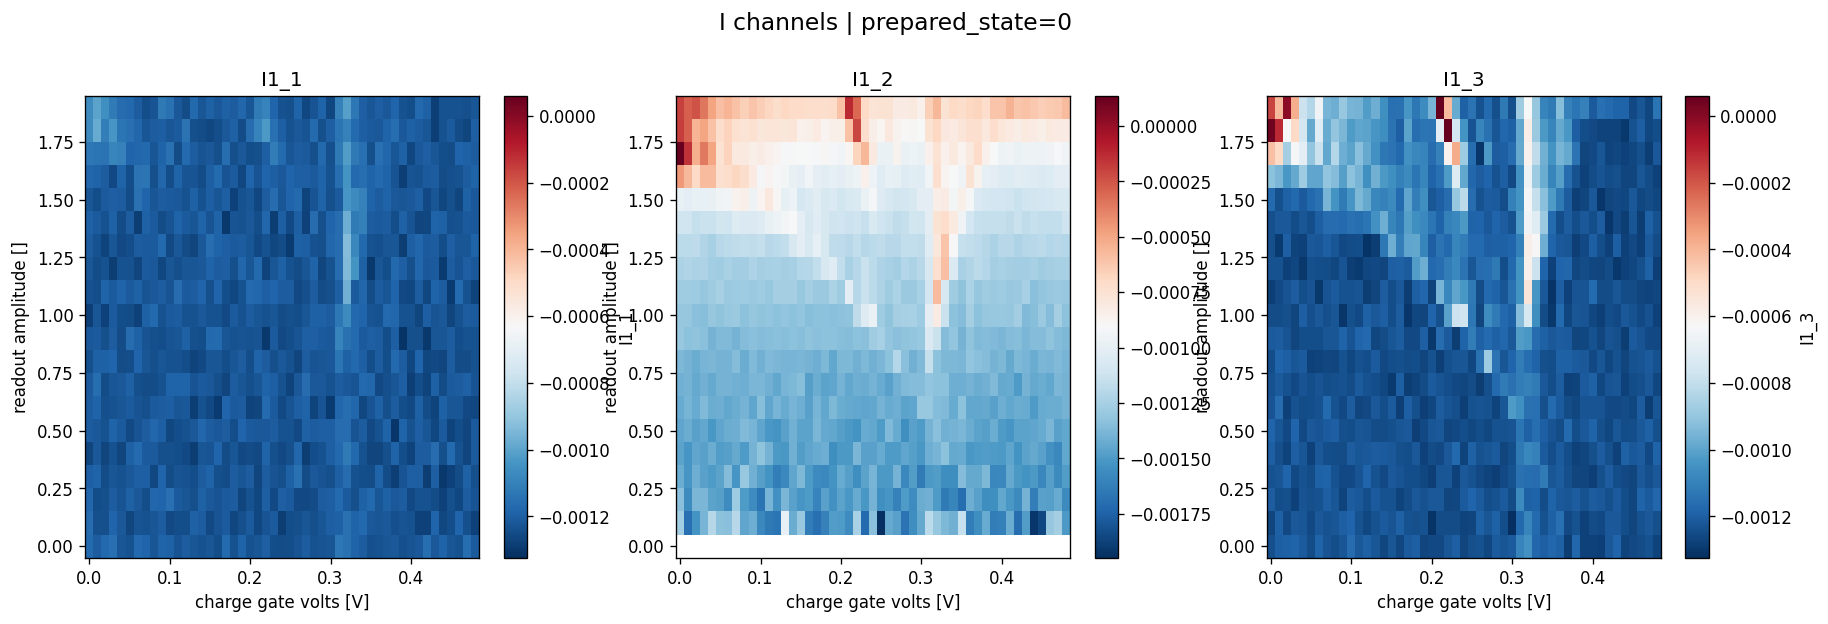

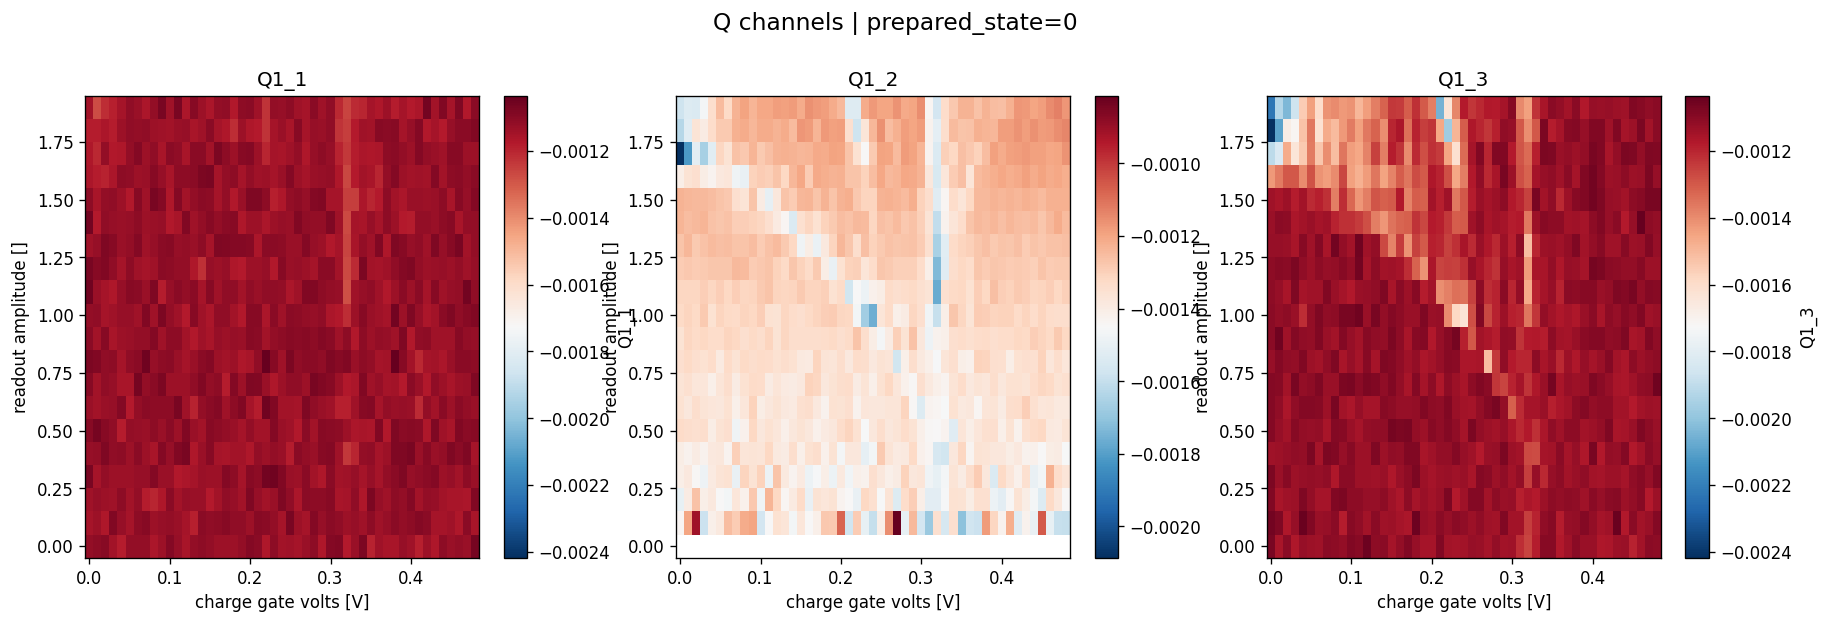

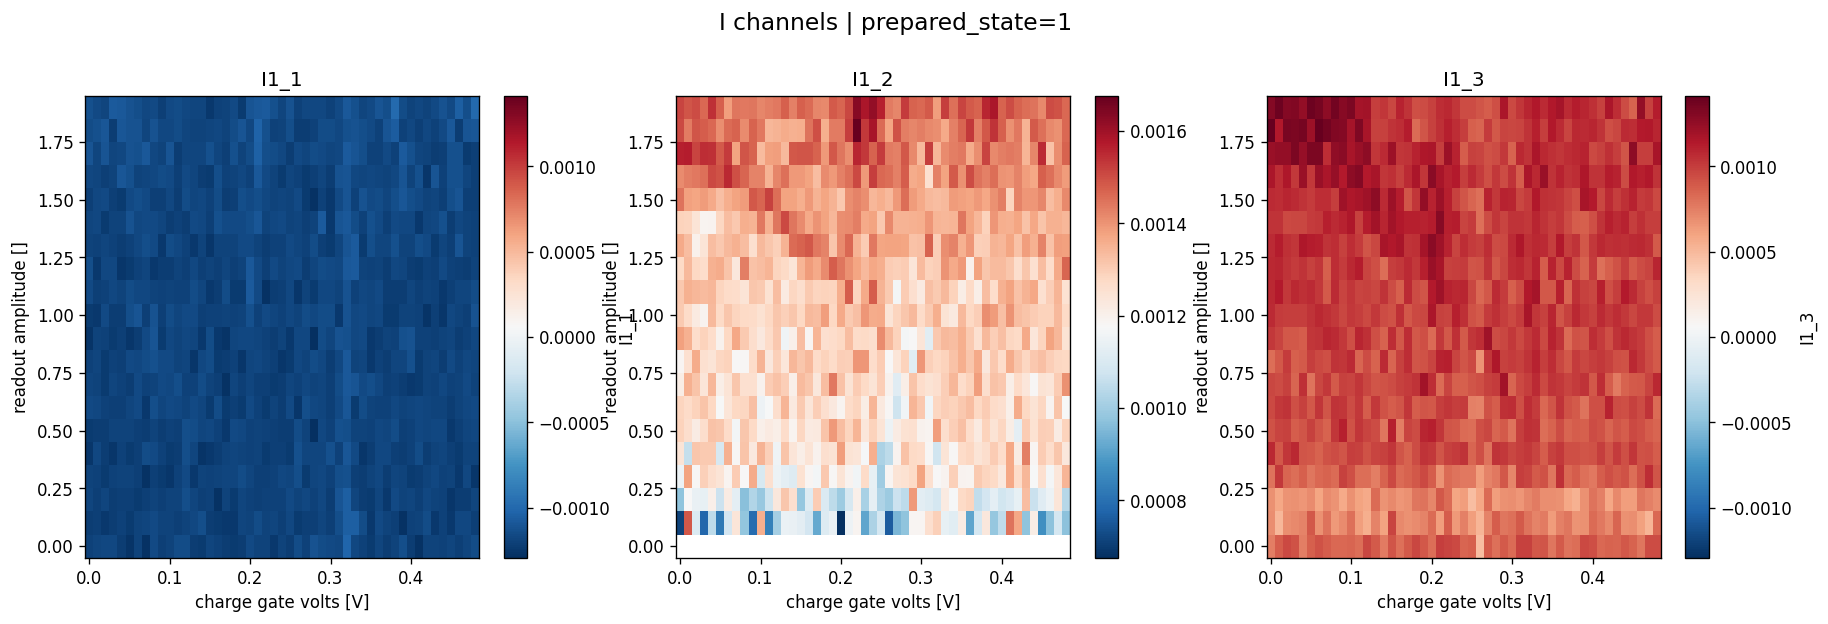

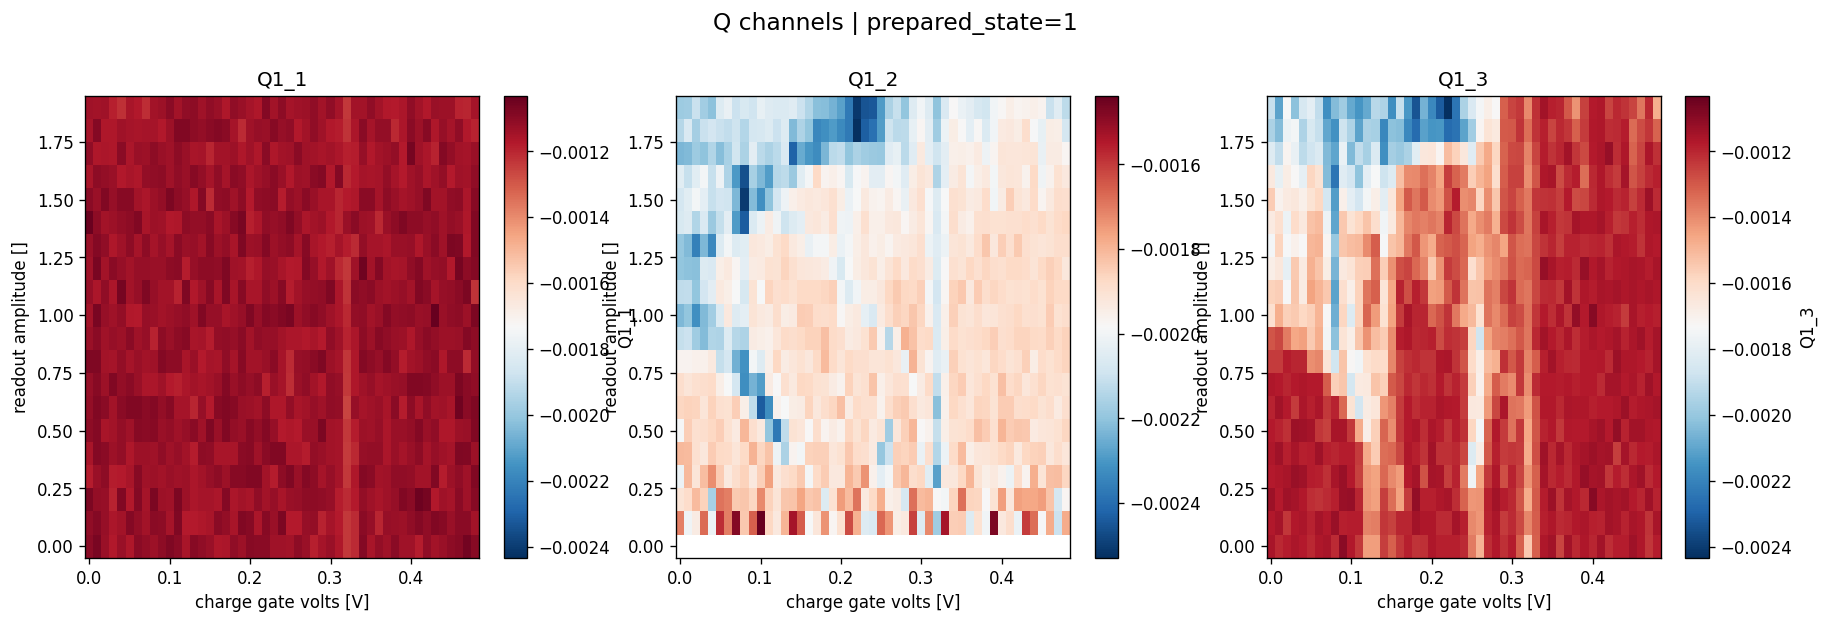

In [6]:
import numpy as np

# Group: I channels and Q channels, subplots for _1, _2, _3
# _1 and _3 share the same colorbar range; _2 has its own
i_vars = ['I1_1', 'I1_2', 'I1_3']
q_vars = ['Q1_1', 'Q1_2', 'Q1_3']
prepared_states = sq_data.coords['prepared_state'].values
print("Prepared states:", prepared_states)
for state in prepared_states:
    for group_label, group_vars in [('I', i_vars), ('Q', q_vars)]:
        # Compute means
        means = [sq_data[v].mean(dim='shot_idx').sel(prepared_state=state) for v in group_vars]

        # Normalize _2 variable by amp_prefactor (skip amp_prefactor == 0)
        amp_vals = means[1].coords['amp_prefactor']
        # print(amp_vals)
        means[1] = means[1].where(amp_vals != 0) / amp_vals.where(amp_vals != 0)
        # print(means)
        # Shared vmin/vmax for _1 and _3 (index 0 and 2)
        shared_vmin = min(float(means[0].min()), float(means[2].min()))
        shared_vmax = max(float(means[0].max()), float(means[2].max()))

        n = len(group_vars)
        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), dpi=120, squeeze=False)
        for j, (var_name, mean_da) in enumerate(zip(group_vars, means)):
            if j in (0, 2):  # _1 and _3 share range
                vmin, vmax = shared_vmin, shared_vmax
            else:            # _2 uses its own range
                vmin, vmax = float(mean_da.min(skipna=True)), float(mean_da.max(skipna=True))
            mean_da.plot.pcolormesh(
                ax=axes[0, j], x='charge_gate', y='amp_prefactor',
                cmap='RdBu_r', add_colorbar=True, vmin=vmin, vmax=vmax
            )
            axes[0, j].set_title(var_name)
        fig.suptitle(f"{group_label} channels | prepared_state={state}", fontsize=14, y=1.02)
        display(fig)
        plt.close(fig)

Nearest charge_gate: 0.25,  Nearest amp_prefactor: 1.4999999999999998


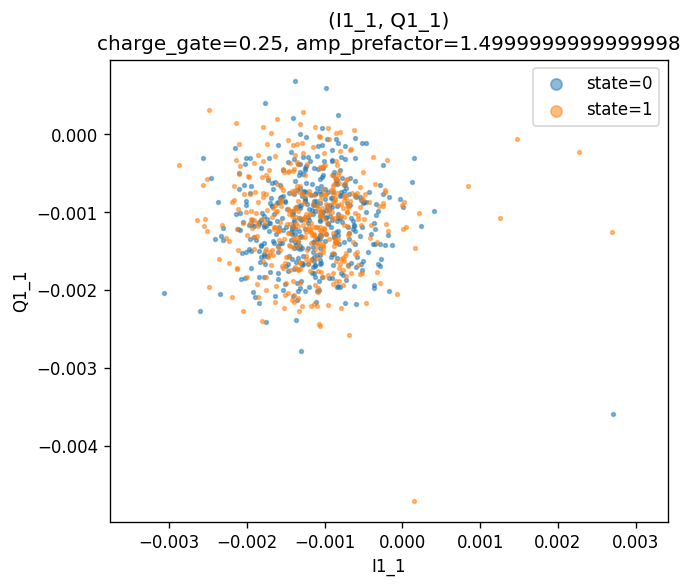

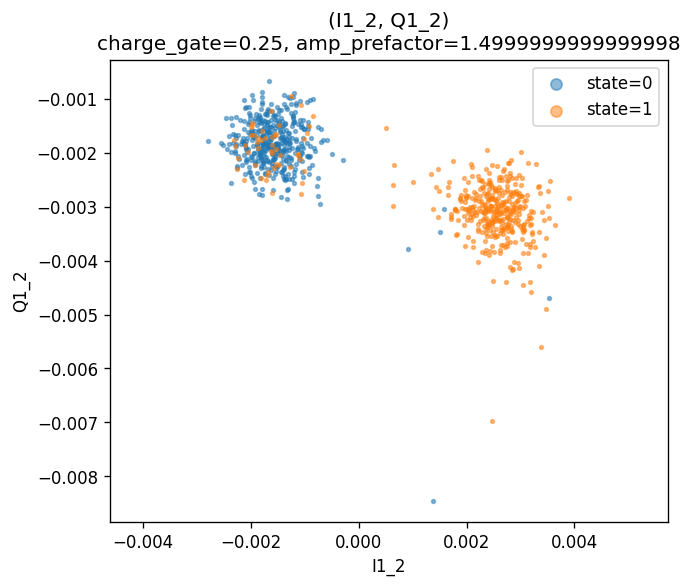

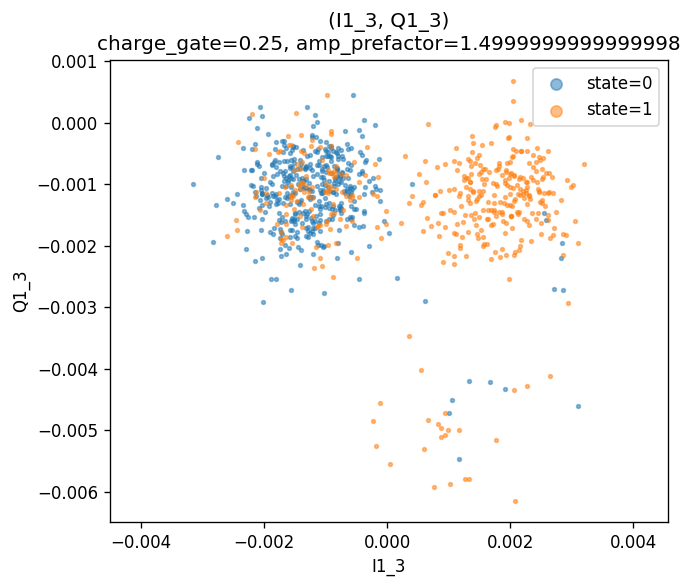

In [7]:
# --- User input: specify charge voltage and readout amplitude ---
target_charge_gate = 0.25      # <-- change this
target_amp_prefactor = 1.5   # <-- change this

# Find nearest coordinate values
charge_gate_vals = sq_data.coords['charge_gate'].values
amp_prefactor_vals = sq_data.coords['amp_prefactor'].values
nearest_cg = charge_gate_vals[np.argmin(np.abs(charge_gate_vals - target_charge_gate))]
nearest_ap = amp_prefactor_vals[np.argmin(np.abs(amp_prefactor_vals - target_amp_prefactor))]
print(f"Nearest charge_gate: {nearest_cg},  Nearest amp_prefactor: {nearest_ap}")

# Select data at nearest point
sel_kw = dict(charge_gate=nearest_cg, amp_prefactor=nearest_ap)

iq_pairs = [('I1_1', 'Q1_1'), ('I1_2', 'Q1_2'), ('I1_3', 'Q1_3')]
colors = plt.cm.tab10.colors

for i_var, q_var in iq_pairs:
    fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
    for idx, state in enumerate(prepared_states):
        i_data = sq_data[i_var].sel(**sel_kw, prepared_state=state).values
        q_data = sq_data[q_var].sel(**sel_kw, prepared_state=state).values
        ax.scatter(i_data, q_data, s=5, alpha=0.5, color=colors[idx % len(colors)], label=f"state={state}")
    ax.set_xlabel(i_var)
    ax.set_ylabel(q_var)
    ax.set_title(f"({i_var}, {q_var})\n"
                 f"charge_gate={nearest_cg}, amp_prefactor={nearest_ap}")
    ax.set_aspect('equal', adjustable='datalim')
    ax.legend(markerscale=3)
    display(fig)
    plt.close(fig)

## 5. Single-State QND Analysis
Select a single (charge_gate, amp_prefactor, prepared_state) slice, build an `xr.Dataset` with only `shot_idx`, and run `SingleStateQNDAnalyzer`.

--- state=0 ---
  Fitted mean: [[-0.00118905 -0.00111317]]
  Fitted std: 0.0005456365929485951
  Outlier probability: 0.014634146341463415


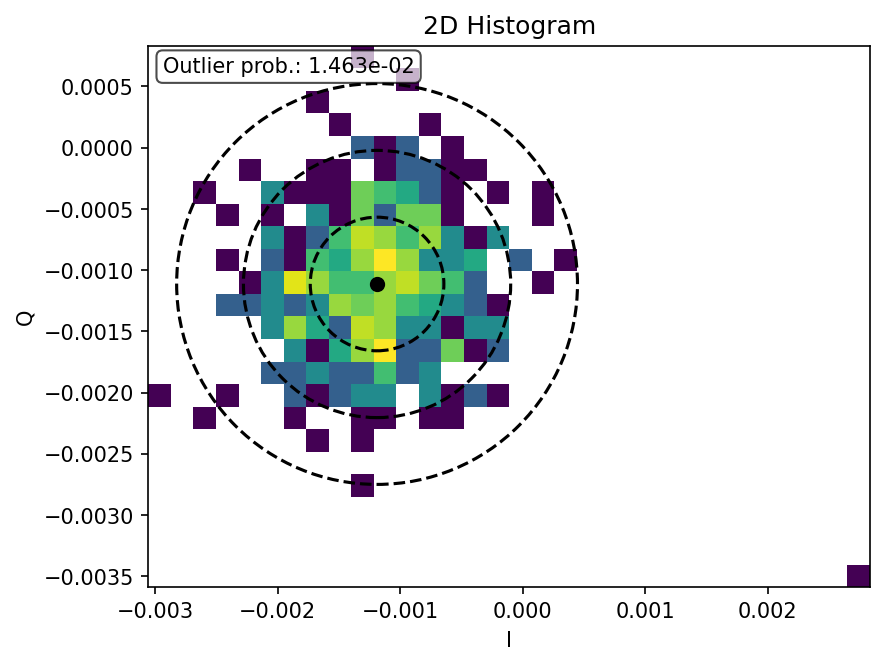

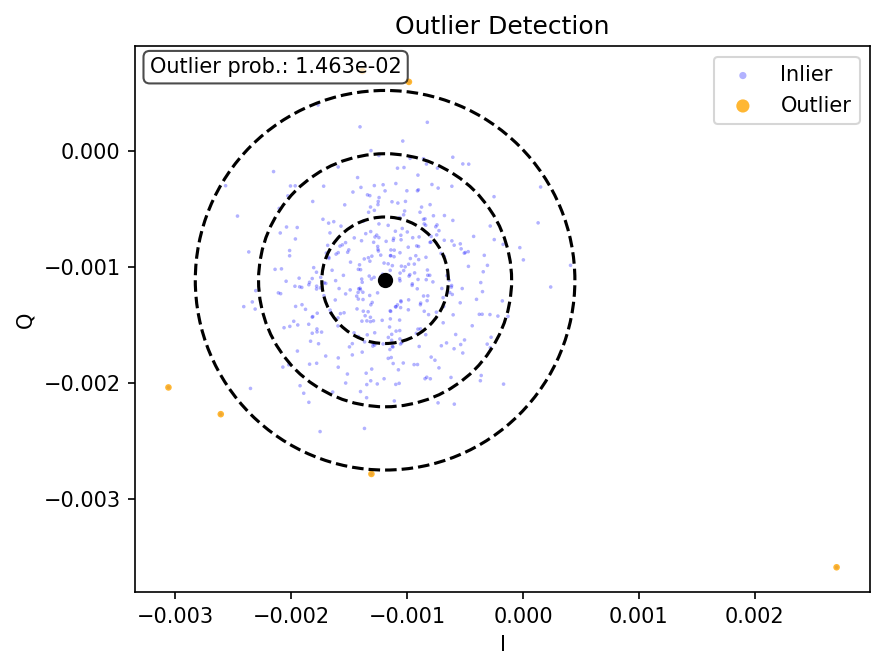

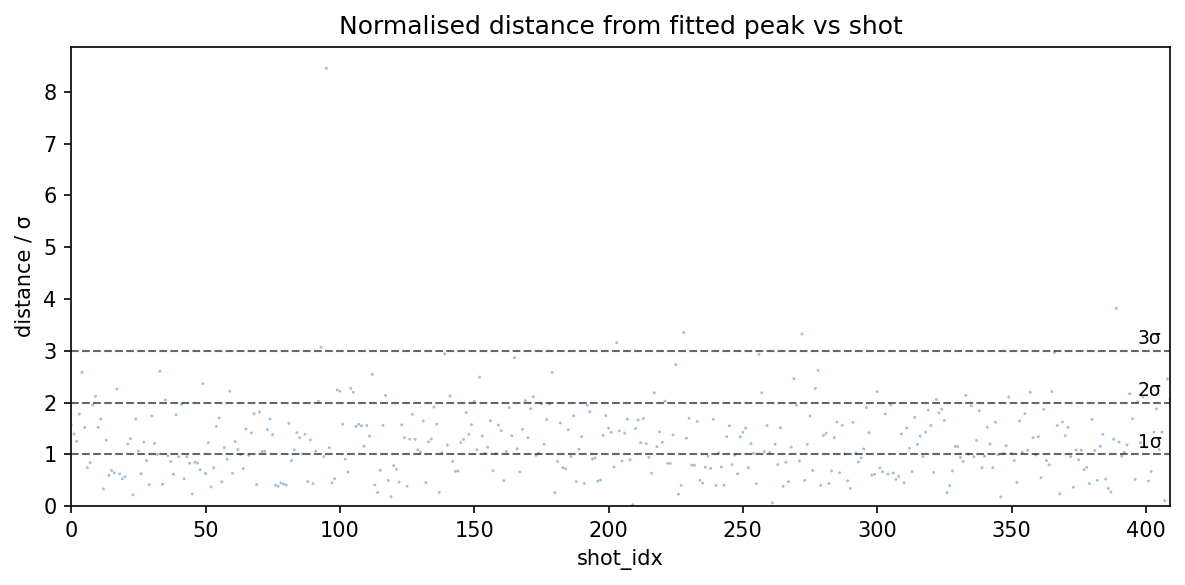

--- state=1 ---
  Fitted mean: [[-0.00117136 -0.00112341]]
  Fitted std: 0.0005264329329399686
  Outlier probability: 0.02195121951219512


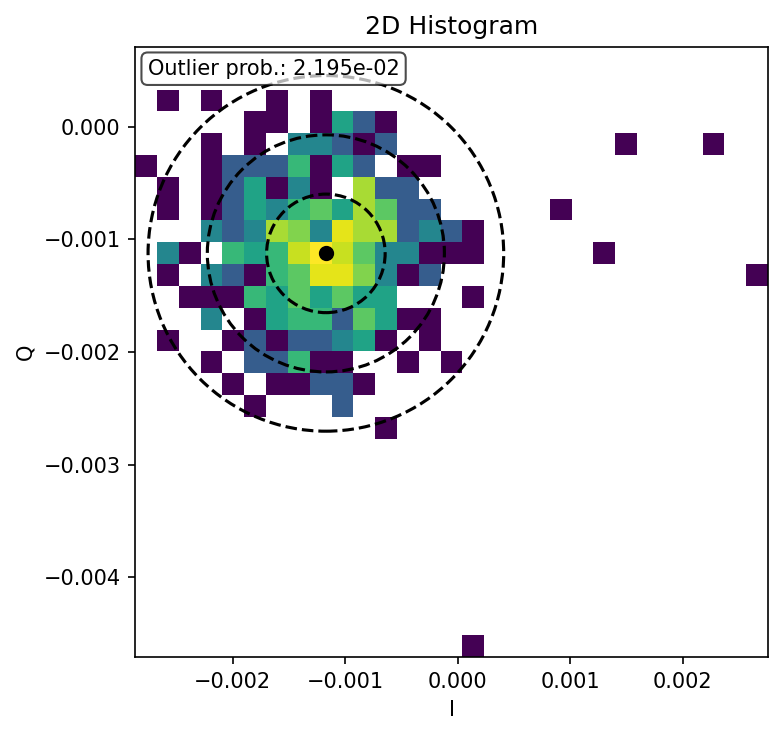

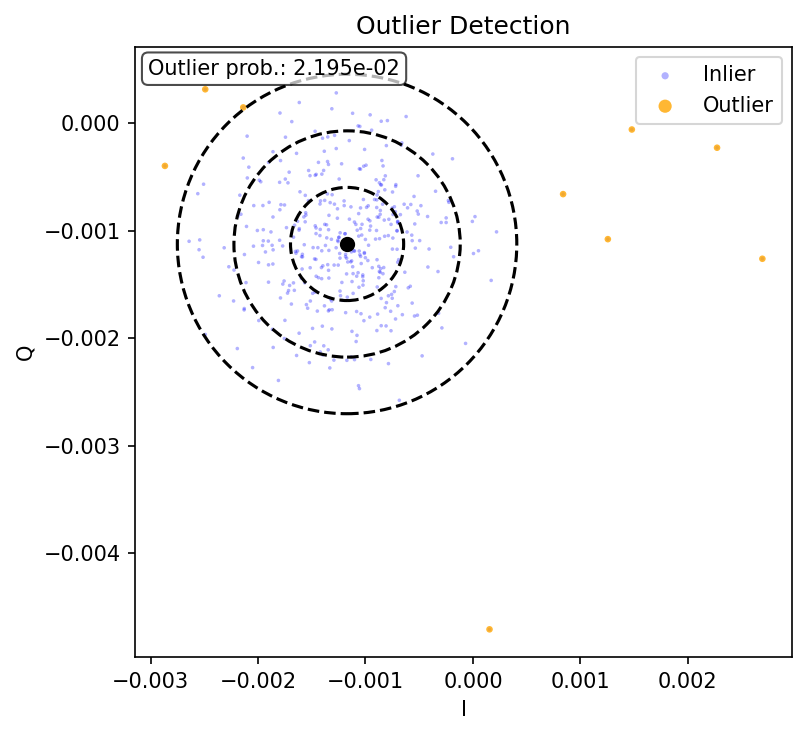

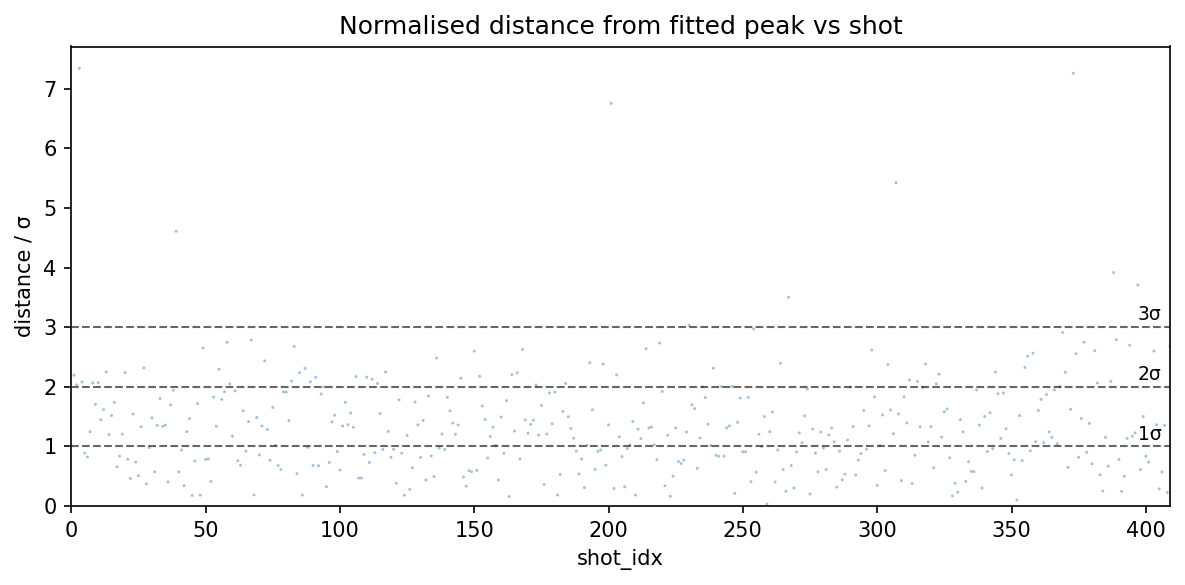

In [ ]:
from scqat.protocols.single_state_QND import SingleStateOutlierAnalyzer

# --- Run SingleStateOutlierAnalyzer for each prepared_state ---
i_var, q_var = 'I1_1', 'Q1_1'

all_results = {}   # {state: results}
all_figs = {}      # {state: figs}

for target_state in prepared_states:
    i_data = sq_data[i_var].sel(**sel_kw, prepared_state=target_state).values
    q_data = sq_data[q_var].sel(**sel_kw, prepared_state=target_state).values

    single_ds = xr.Dataset(
        {
            'I': ('shot_idx', i_data),
            'Q': ('shot_idx', q_data),
        },
        coords={'shot_idx': np.arange(len(i_data))},
    )

    analyzer = SingleStateOutlierAnalyzer()
    results, figs = analyzer.analyze(single_ds, outlier_sigma=3)
    all_results[target_state] = results
    all_figs[target_state] = figs

    print(f"--- state={target_state} ---")
    print("  Fitted mean:", results['fitted_paras']['mean'])
    print("  Fitted std:", results['fitted_paras']['std'])
    print("  Outlier probability:", results['outlier_probability'])

    for name, fig in figs.items():
        display(fig)
        plt.close(fig)

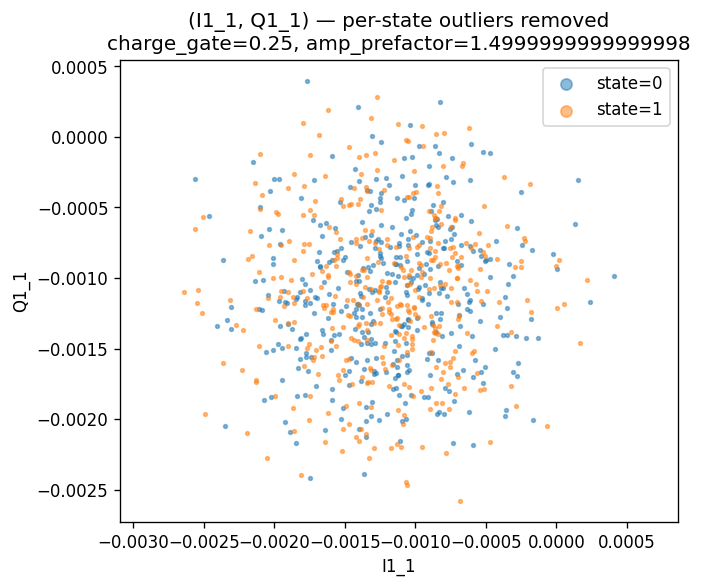

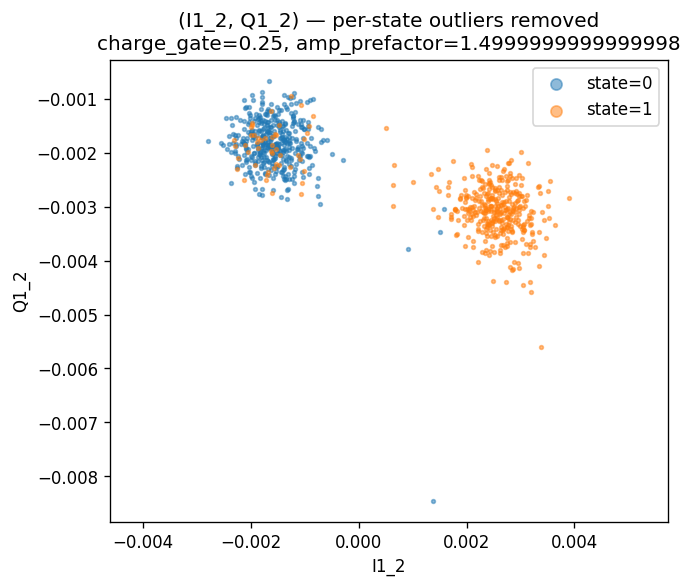

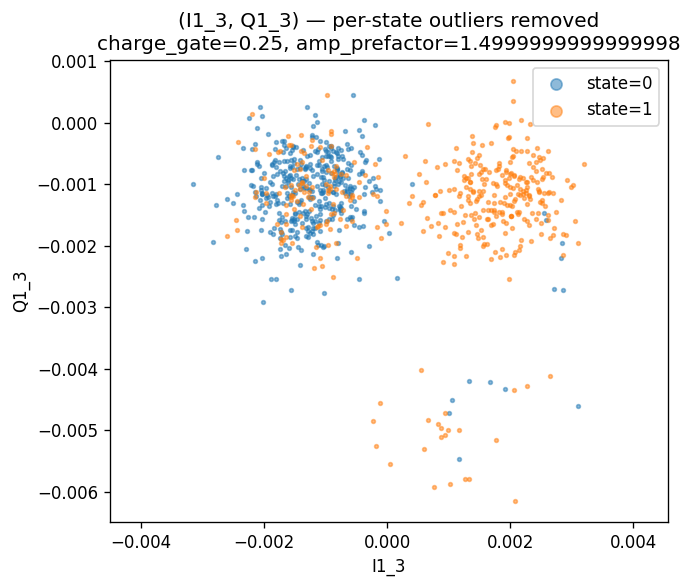

In [9]:
# --- Re-plot IQ scatter with per-state outliers removed ---
for i_var, q_var in iq_pairs:
    fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
    for idx, state in enumerate(prepared_states):
        i_data = sq_data[i_var].sel(**sel_kw, prepared_state=state).values
        q_data = sq_data[q_var].sel(**sel_kw, prepared_state=state).values
        # Each state uses its own inlier mask from (I1_1, Q1_1)
        inlier_mask = ~all_results[state]['outlier_mask']
        i_data = i_data[inlier_mask]
        q_data = q_data[inlier_mask]
        ax.scatter(i_data, q_data, s=5, alpha=0.5, color=colors[idx % len(colors)], label=f"state={state}")
    ax.set_xlabel(i_var)
    ax.set_ylabel(q_var)
    ax.set_title(f"({i_var}, {q_var}) — per-state outliers removed\n"
                 f"charge_gate={nearest_cg}, amp_prefactor={nearest_ap}")
    ax.set_aspect('equal', adjustable='datalim')
    ax.legend(markerscale=3)
    display(fig)
    plt.close(fig)

Global mean I: -0.001, Global mean Q: -0.001, Half std: 0.000


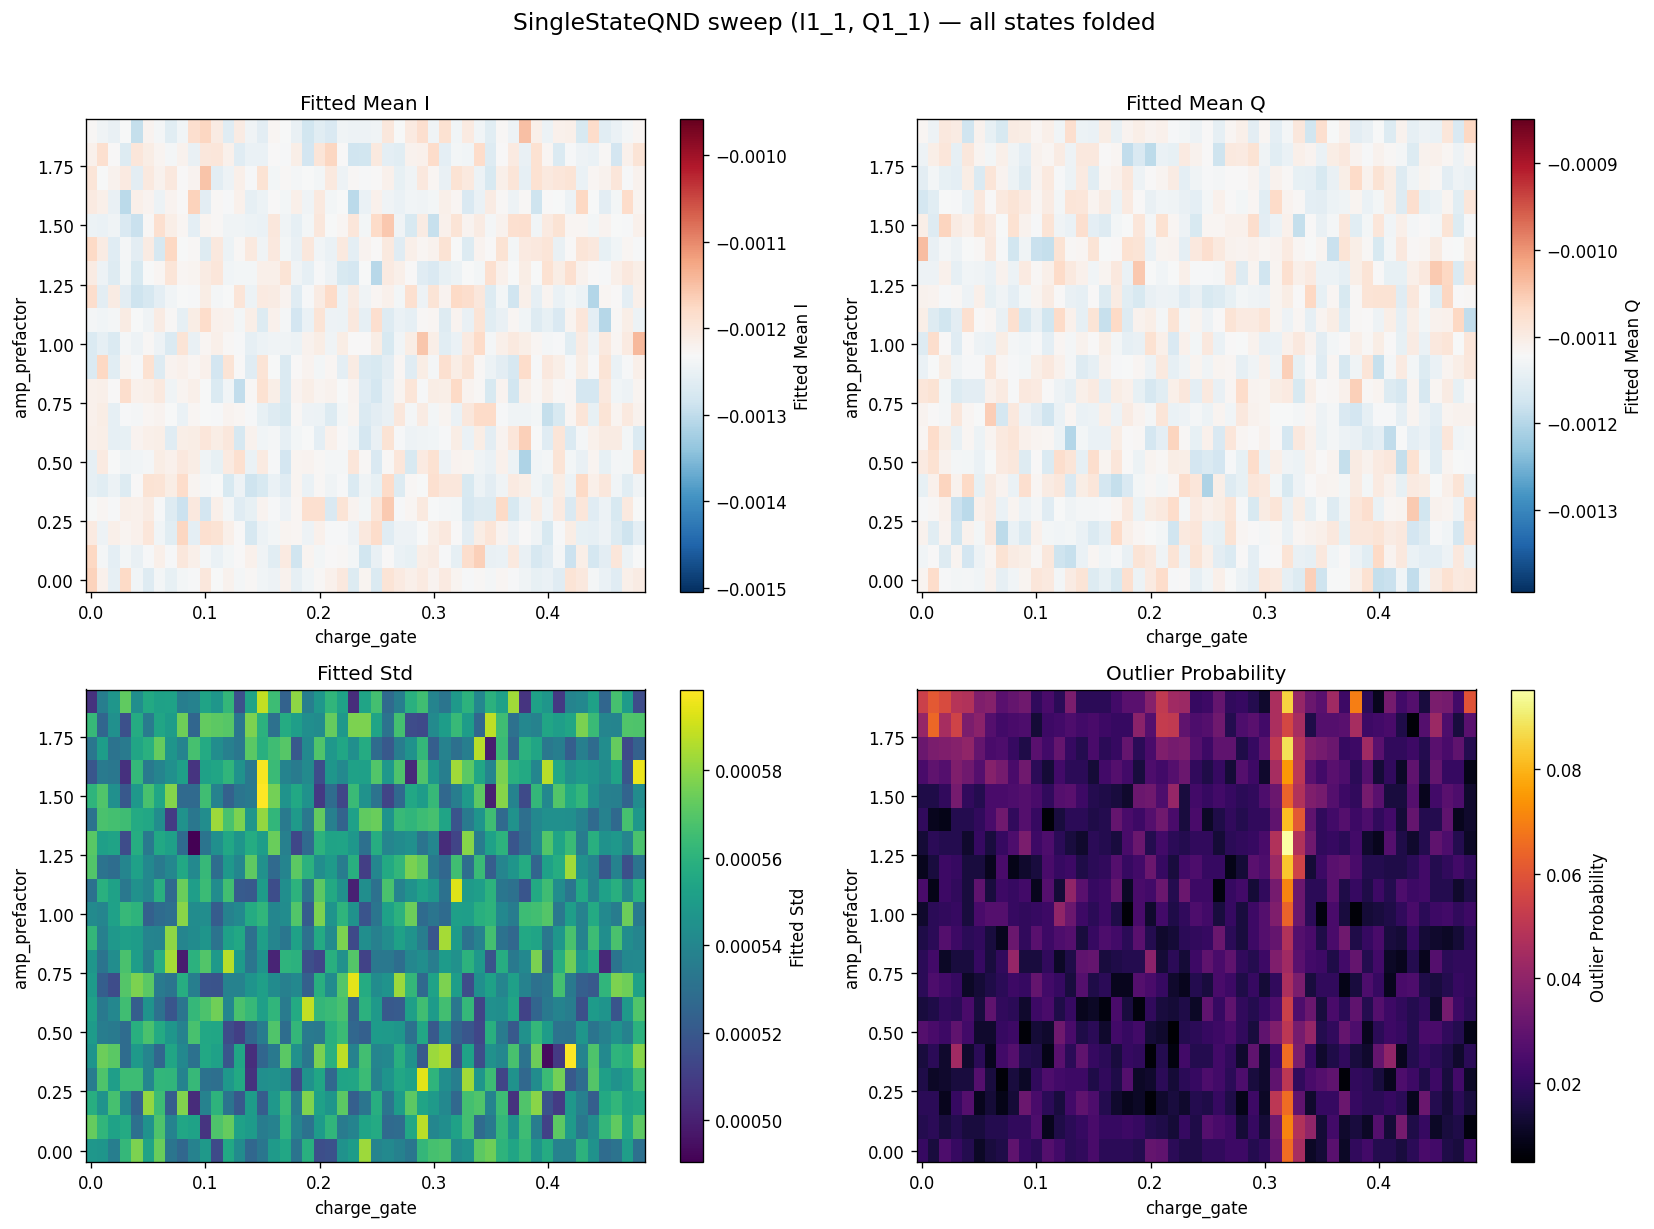

In [ ]:
from scqat.protocols.single_state_QND import SingleStateOutlierAnalyzer

i_var, q_var = 'I1_1', 'Q1_1'
charge_gate_vals = sq_data.coords['charge_gate'].values
amp_prefactor_vals = sq_data.coords['amp_prefactor'].values
prepared_states = sq_data.coords['prepared_state'].values

n_cg = len(charge_gate_vals)
n_ap = len(amp_prefactor_vals)

# Storage arrays
mean_I = np.full((n_ap, n_cg), np.nan)
mean_Q = np.full((n_ap, n_cg), np.nan)
fitted_std = np.full((n_ap, n_cg), np.nan)
outlier_prob = np.full((n_ap, n_cg), np.nan)

analyzer = SingleStateOutlierAnalyzer()

for i, ap in enumerate(amp_prefactor_vals):
    for j, cg in enumerate(charge_gate_vals):
        # Fold prepared_state into shot_idx
        i_all = []
        q_all = []
        for state in prepared_states:
            i_all.append(sq_data[i_var].sel(charge_gate=cg, amp_prefactor=ap, prepared_state=state).values)
            q_all.append(sq_data[q_var].sel(charge_gate=cg, amp_prefactor=ap, prepared_state=state).values)
        i_concat = np.concatenate(i_all)
        q_concat = np.concatenate(q_all)

        single_ds = xr.Dataset(
            {'I': ('shot_idx', i_concat), 'Q': ('shot_idx', q_concat)},
            coords={'shot_idx': np.arange(len(i_concat))},
        )

        try:
            results, _ = analyzer.analyze(single_ds, outlier_sigma=3, skip_figures=True)
            mean_I[i, j] = results['fitted_paras']['mean'][0, 0]
            mean_Q[i, j] = results['fitted_paras']['mean'][0, 1]
            fitted_std[i, j] = results['fitted_paras']['std']
            outlier_prob[i, j] = results['outlier_probability']
        except Exception as e:
            print(f"Failed at amp_prefactor={ap}, charge_gate={cg}: {e}")



Global mean I: -0.001, Global mean Q: -0.001, Half std: 0.000
Mean I  — min: -1.3159e-03, max: -1.1436e-03
Mean Q  — min: -1.2067e-03, max: -1.0382e-03


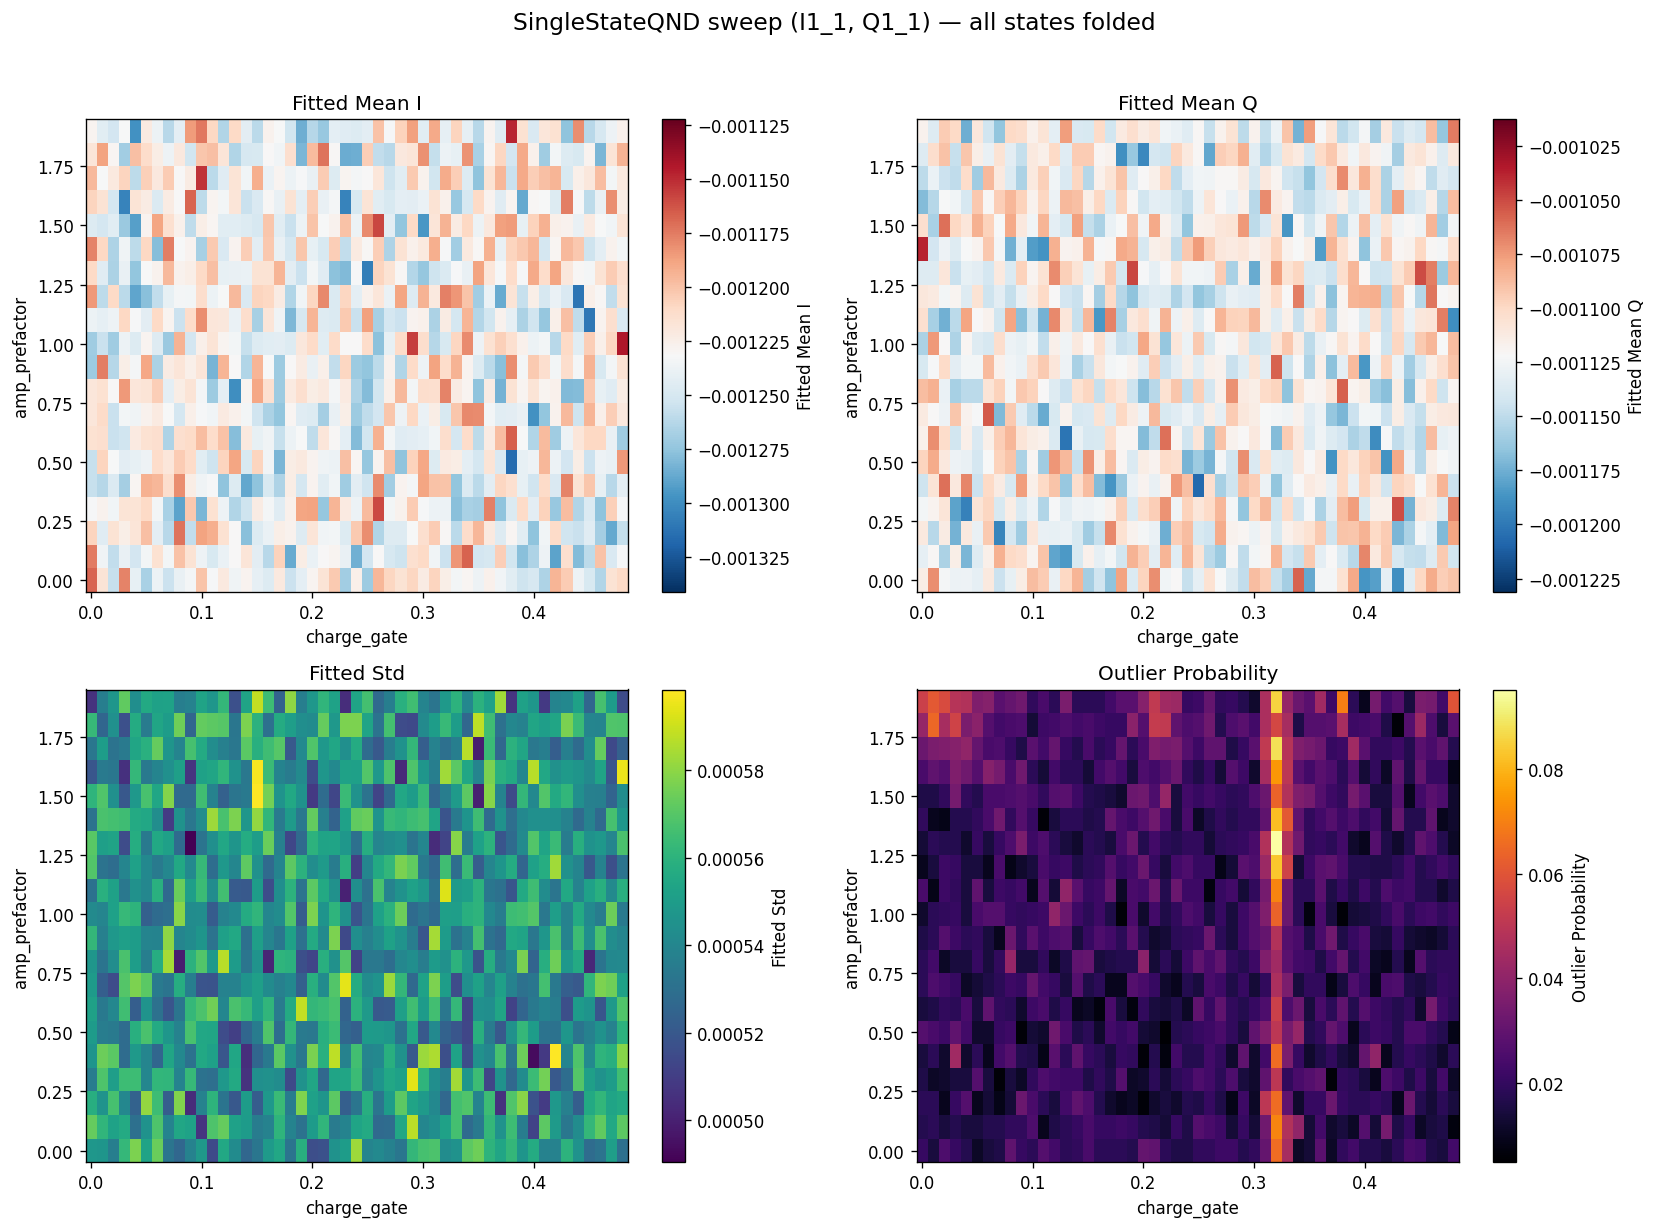

In [17]:
# Build xarray DataArrays for plotting
coords_2d = {'amp_prefactor': amp_prefactor_vals, 'charge_gate': charge_gate_vals}
da_mean_I = xr.DataArray(mean_I, dims=['amp_prefactor', 'charge_gate'], coords=coords_2d, name='Fitted Mean I')
da_mean_Q = xr.DataArray(mean_Q, dims=['amp_prefactor', 'charge_gate'], coords=coords_2d, name='Fitted Mean Q')
da_std = xr.DataArray(fitted_std, dims=['amp_prefactor', 'charge_gate'], coords=coords_2d, name='Fitted Std')
da_outlier = xr.DataArray(outlier_prob, dims=['amp_prefactor', 'charge_gate'], coords=coords_2d, name='Outlier Probability')

# Colorbar range for mean I/Q: global_mean ± 0.5 * global_mean_std
global_mean_I = float(np.nanmean(mean_I))
global_mean_Q = float(np.nanmean(mean_Q))
half_std = 0.2 * float(np.nanmean(fitted_std))
print(f"Global mean I: {global_mean_I:.3f}, Global mean Q: {global_mean_Q:.3f}, Half std: {half_std:.3f}")
print(f"Mean I  — min: {np.nanmin(mean_I):.4e}, max: {np.nanmax(mean_I):.4e}")
print(f"Mean Q  — min: {np.nanmin(mean_Q):.4e}, max: {np.nanmax(mean_Q):.4e}")

# Plot 2x2 colormaps
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)
for ax, da, cmap, vlims in zip(
    axes.flat,
    [da_mean_I, da_mean_Q, da_std, da_outlier],
    ['RdBu_r', 'RdBu_r', 'viridis', 'inferno'],
    [
        (global_mean_I - half_std, global_mean_I + half_std),
        (global_mean_Q - half_std, global_mean_Q + half_std),
        (None, None),
        (None, None),
    ],
):
    kw = dict(ax=ax, x='charge_gate', y='amp_prefactor', cmap=cmap, add_colorbar=True)
    if vlims[0] is not None:
        kw.update(vmin=vlims[0], vmax=vlims[1])
    da.plot.pcolormesh(**kw)
    ax.set_title(da.name)
fig.suptitle(f"SingleStateQND sweep ({i_var}, {q_var}) — all states folded", fontsize=14, y=1.02)
fig.tight_layout()
display(fig)
plt.close(fig)